In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/airline_customer_satisfaction.csv")

In [3]:
#data overview
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [4]:
#how many satisfied and dissatisfied passangers are there?
df['satisfaction'].value_counts()
df['satisfaction'].value_counts(normalize=True)

satisfaction
satisfied       0.547328
dissatisfied    0.452672
Name: proportion, dtype: float64

In [5]:
df.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [6]:
#delay's influance on satisfaction
df.groupby('satisfaction')[['Departure Delay in Minutes', 
                            'Arrival Delay in Minutes']].mean()

,Departure Delay in Minutes,Arrival Delay in Minutes
satisfaction,,
dissatisfied,17.807749,18.504599
satisfied,12.154768,12.268883


In [7]:
df.groupby('satisfaction')['Departure Delay in Minutes'].median()

satisfaction
dissatisfied    0.0
satisfied       0.0
Name: Departure Delay in Minutes, dtype: float64

In [8]:
df.groupby('satisfaction')['Departure Delay in Minutes'].describe()

,count,mean,std,min,25%,50%,75%,max
satisfaction,,,,,,,,
dissatisfied,58793.0,17.807749,43.513060,0.0,0.0,0.0,16.0,1592.0
satisfied,71087.0,12.154768,32.676796,0.0,0.0,0.0,9.0,1305.0


In [9]:
df['delay_30_plus'] = df['Departure Delay in Minutes'] > 30
df.groupby('satisfaction')['delay_30_plus'].mean()

satisfaction
dissatisfied    0.165326
satisfied       0.117856
Name: delay_30_plus, dtype: float64

In [10]:
df['delay_60_plus'] = df['Departure Delay in Minutes'] > 60
df.groupby('satisfaction')['delay_60_plus'].mean()

satisfaction
dissatisfied    0.085980
satisfied       0.055144
Name: delay_60_plus, dtype: float64

In [11]:
#rating by groups of services
rating_cols = [
    'Seat comfort',
    'Departure/Arrival time convenient',
    'Food and drink',
    'Gate location',
    'Inflight wifi service',
    'Inflight entertainment',
    'Online support',
    'Ease of Online booking',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Cleanliness',
    'Online boarding'
]

In [12]:
grouped = df.groupby('satisfaction')[rating_cols].mean()
grouped.round(3)

,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding
satisfaction,,,,,,,,,,,,,,
dissatisfied,2.467,3.017,2.66,3.008,2.920,2.609,2.959,2.852,2.973,3.053,3.365,2.972,3.377,2.870
satisfied,3.146,2.969,3.01,2.976,3.521,4.024,3.983,3.985,3.872,3.844,3.969,3.646,3.977,3.752


In [13]:
#satisfied vs dissatisfied - mean difference between categories
difference = grouped.loc['satisfied'] - grouped.loc['dissatisfied']
difference.sort_values(ascending=False)

Inflight entertainment               1.415664
Ease of Online booking               1.132490
Online support                       1.024047
On-board service                     0.898820
Online boarding                      0.882271
Leg room service                     0.791622
Seat comfort                         0.678318
Checkin service                      0.674105
Baggage handling                     0.604887
Inflight wifi service                0.601605
Cleanliness                          0.600070
Food and drink                       0.350019
Gate location                       -0.031670
Departure/Arrival time convenient   -0.047577
dtype: float64

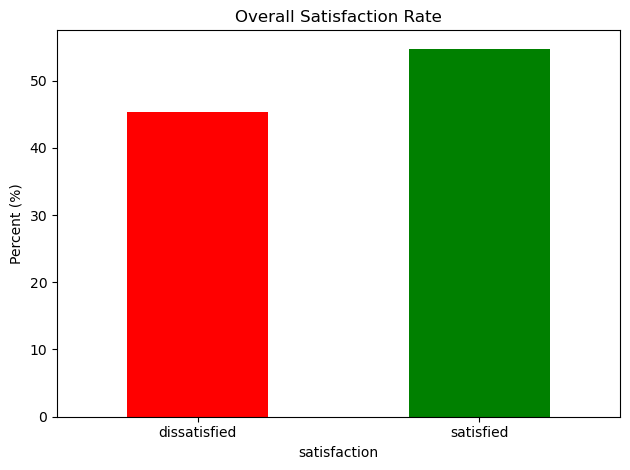

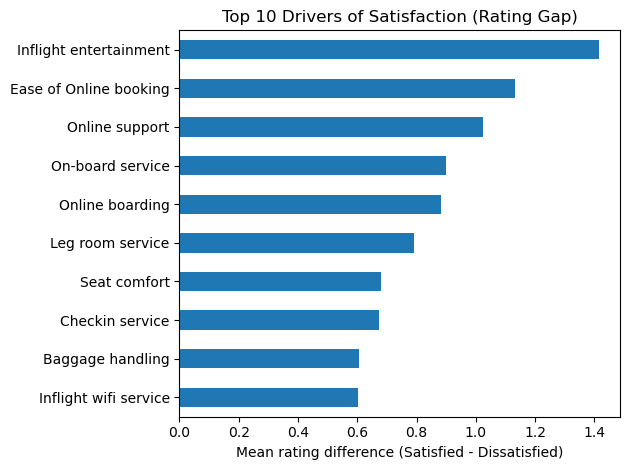

In [14]:
sat_rate = df['satisfaction'].value_counts(normalize=True).sort_index() * 100

plt.figure()
sat_rate.plot(kind='bar', color=['red', 'green'])
plt.ylabel('Percent (%)')
plt.title('Overall Satisfaction Rate')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../images/01_overall_satisfaction_rate.png", bbox_inches="tight")
plt.show()

means_by_sat = df.groupby('satisfaction')[rating_cols].mean()

gap = (means_by_sat.loc['satisfied'] - means_by_sat.loc['dissatisfied']).sort_values(ascending=False)

top10_gap = gap.head(10).sort_values()  # sort rosnąco, żeby ładnie wyglądało na wykresie poziomym

plt.figure()
top10_gap.plot(kind='barh')
plt.xlabel('Mean rating difference (Satisfied - Dissatisfied)')
plt.title('Top 10 Drivers of Satisfaction (Rating Gap)')
plt.tight_layout()

plt.savefig("../images/02_top10_driver_gap.png", bbox_inches="tight")
plt.show()

In [15]:
df.groupby('Class')['satisfaction'].value_counts(normalize=True)

Class     satisfaction
Business  satisfied       0.709379
          dissatisfied    0.290621
Eco       dissatisfied    0.606013
          satisfied       0.393987
Eco Plus  dissatisfied    0.572947
          satisfied       0.427053
Name: proportion, dtype: float64

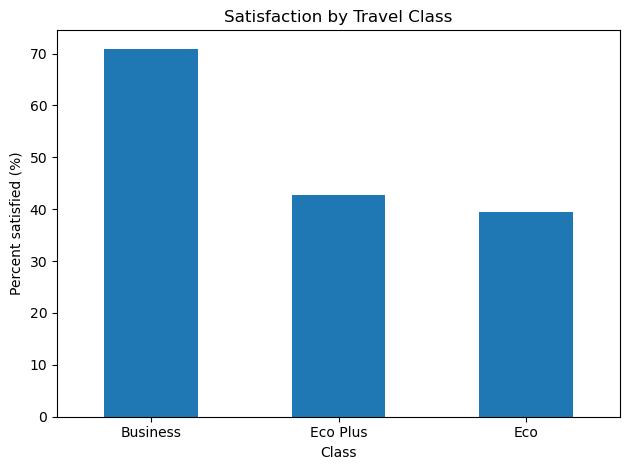

In [16]:
class_rate = (
    df.groupby('Class')['satisfaction']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)

# filtrujemy tylko "satisfied"
class_satisfied = class_rate[class_rate['satisfaction'] == 'satisfied'].set_index('Class')['proportion'] * 100
class_satisfied = class_satisfied.sort_values(ascending=False)

plt.figure()
class_satisfied.plot(kind='bar')
plt.ylabel('Percent satisfied (%)')
plt.title('Satisfaction by Travel Class')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../images/03_satisfaction_by_class.png", bbox_inches="tight")
plt.show()

In [17]:
eco_df = df[df['Class'] == 'Eco']
eco_grouped = eco_df.groupby('satisfaction')[rating_cols].mean()
eco_diff = eco_grouped.loc['satisfied'] - eco_grouped.loc['dissatisfied']
eco_diff.sort_values(ascending=False)

Inflight entertainment               1.314661
Seat comfort                         0.973122
Ease of Online booking               0.904404
Online support                       0.821571
Online boarding                      0.682083
On-board service                     0.613279
Inflight wifi service                0.551892
Food and drink                       0.498839
Leg room service                     0.480771
Checkin service                      0.412712
Baggage handling                     0.289175
Cleanliness                          0.288780
Departure/Arrival time convenient   -0.025609
Gate location                       -0.046925
dtype: float64

In [18]:
eco_plus_df = df[df['Class'] == 'Eco Plus']
eco_plus_grouped = eco_plus_df.groupby('satisfaction')[rating_cols].mean()
eco_plus_diff = eco_plus_grouped.loc['satisfied'] - eco_plus_grouped.loc['dissatisfied']
eco_plus_diff.sort_values(ascending=False)

Inflight entertainment               1.304190
Ease of Online booking               1.163726
Seat comfort                         1.068357
Online support                       0.982965
Online boarding                      0.904773
Inflight wifi service                0.791435
On-board service                     0.620572
Checkin service                      0.467038
Leg room service                     0.416163
Food and drink                       0.261640
Baggage handling                     0.219923
Cleanliness                          0.214004
Gate location                       -0.018377
Departure/Arrival time convenient   -0.176137
dtype: float64

In [19]:
business_df = df[df['Class'] == 'Business']
business_grouped = business_df.groupby('satisfaction')[rating_cols].mean()
business_diff = business_grouped.loc['satisfied'] - business_grouped.loc['dissatisfied']
business_diff.sort_values(ascending=False)

Ease of Online booking               1.378716
Inflight entertainment               1.365642
On-board service                     1.137621
Online support                       1.123587
Leg room service                     1.121747
Online boarding                      1.104161
Cleanliness                          0.930917
Baggage handling                     0.929356
Checkin service                      0.883635
Inflight wifi service                0.638378
Seat comfort                         0.526299
Food and drink                       0.176286
Departure/Arrival time convenient    0.077669
Gate location                       -0.017317
dtype: float64

In [20]:
#flight distance grouping
df['Flight Distance'].describe()

count    129880.000000
mean       1981.409055
std        1027.115606
min          50.000000
25%        1359.000000
50%        1925.000000
75%        2544.000000
max        6951.000000
Name: Flight Distance, dtype: float64

In [21]:
df['haul_type'] = pd.qcut(
    df['Flight Distance'],
    q=3,
    labels=['Short', 'Medium', 'Long']
)

In [22]:
df.groupby('haul_type')['satisfaction'].value_counts(normalize=True)

/var/folders/7w/89t_pkpx3lz16gymgp29ygnm0000gn/T/ipykernel_67323/3220923768.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('haul_type')['satisfaction'].value_counts(normalize=True)


haul_type  satisfaction
Short      satisfied       0.615845
           dissatisfied    0.384155
Medium     dissatisfied    0.547538
           satisfied       0.452462
Long       satisfied       0.573747
           dissatisfied    0.426253
Name: proportion, dtype: float64

In [23]:
long_df = df[df['haul_type'] == 'Long']

long_grouped = long_df.groupby('satisfaction')[rating_cols].mean()
long_diff = long_grouped.loc['satisfied'] - long_grouped.loc['dissatisfied']
long_diff.sort_values(ascending=False)

Inflight entertainment               1.497635
Ease of Online booking               1.215279
Online support                       1.150881
Online boarding                      1.026765
On-board service                     0.925546
Inflight wifi service                0.798783
Leg room service                     0.775435
Checkin service                      0.764309
Baggage handling                     0.683331
Cleanliness                          0.662600
Seat comfort                         0.603447
Food and drink                       0.309842
Gate location                       -0.025617
Departure/Arrival time convenient   -0.068489
dtype: float64

In [24]:
medium_df = df[df['haul_type'] == 'Medium']

medium_grouped = medium_df.groupby('satisfaction')[rating_cols].mean()
medium_diff = medium_grouped.loc['satisfied'] - medium_grouped.loc['dissatisfied']
medium_diff.sort_values(ascending=False)

Inflight entertainment               1.461615
Online support                       0.990887
Ease of Online booking               0.974587
Online boarding                      0.811507
Seat comfort                         0.805613
On-board service                     0.727543
Leg room service                     0.600824
Checkin service                      0.588741
Inflight wifi service                0.580637
Food and drink                       0.480959
Cleanliness                          0.386323
Baggage handling                     0.371275
Departure/Arrival time convenient   -0.024544
Gate location                       -0.049960
dtype: float64

In [25]:
#satisfaction by client group

In [26]:
df.groupby('Customer Type')['satisfaction'].value_counts(normalize=True)

Customer Type      satisfaction
Loyal Customer     satisfied       0.616277
                   dissatisfied    0.383723
disloyal Customer  dissatisfied    0.760303
                   satisfied       0.239697
Name: proportion, dtype: float64

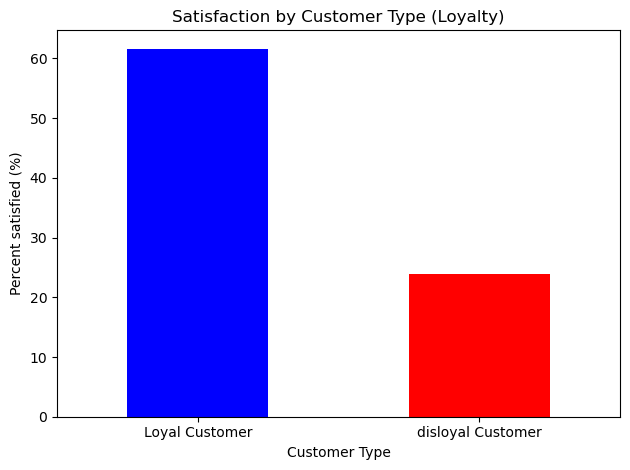

In [27]:
loyal_rate = (
    df.groupby('Customer Type')['satisfaction']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)

loyal_satisfied = loyal_rate[loyal_rate['satisfaction'] == 'satisfied'].set_index('Customer Type')['proportion'] * 100
loyal_satisfied = loyal_satisfied.sort_values(ascending=False)

plt.figure()
loyal_satisfied.plot(kind='bar', color=['blue','red'])
plt.ylabel('Percent satisfied (%)')
plt.title('Satisfaction by Customer Type (Loyalty)')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()

plt.savefig("../images/04_satisfaction_by_loyalty.png", bbox_inches="tight")
plt.show()

In [28]:
#Type of travel group
df.groupby('Type of Travel')['satisfaction'].value_counts(normalize=True)

Type of Travel   satisfaction
Business travel  satisfied       0.583724
                 dissatisfied    0.416276
Personal Travel  dissatisfied    0.533904
                 satisfied       0.466096
Name: proportion, dtype: float64

In [29]:
df.groupby(['Customer Type', 'Class'])['satisfaction'].value_counts(normalize=True)

Customer Type      Class     satisfaction
Loyal Customer     Business  satisfied       0.763910
                             dissatisfied    0.236090
                   Eco       dissatisfied    0.529759
                             satisfied       0.470241
                   Eco Plus  dissatisfied    0.535546
                             satisfied       0.464454
disloyal Customer  Business  dissatisfied    0.603293
                             satisfied       0.396707
                   Eco       dissatisfied    0.855875
                             satisfied       0.144125
                   Eco Plus  dissatisfied    0.920219
                             satisfied       0.079781
Name: proportion, dtype: float64

In [30]:
df.groupby(['Customer Type', 'haul_type'])['satisfaction'].value_counts(normalize=True)

/var/folders/7w/89t_pkpx3lz16gymgp29ygnm0000gn/T/ipykernel_67323/1607031628.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Customer Type', 'haul_type'])['satisfaction'].value_counts(normalize=True)


Customer Type      haul_type  satisfaction
Loyal Customer     Short      satisfied       0.671087
                              dissatisfied    0.328913
                   Medium     satisfied       0.534318
                              dissatisfied    0.465682
                   Long       satisfied       0.629568
                              dissatisfied    0.370432
disloyal Customer  Short      dissatisfied    0.773852
                              satisfied       0.226148
                   Medium     dissatisfied    0.761599
                              satisfied       0.238401
                   Long       dissatisfied    0.746534
                              satisfied       0.253466
Name: proportion, dtype: float64

In [31]:
#Grouping by age group
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Young (0-25)', 'Adult (26-40)', 'Mature (41-60)', 'Senior (60+)']
)

In [32]:
df.groupby('age_group')['satisfaction'].value_counts(normalize=True)

/var/folders/7w/89t_pkpx3lz16gymgp29ygnm0000gn/T/ipykernel_67323/2664830832.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['satisfaction'].value_counts(normalize=True)


age_group       satisfaction
Young (0-25)    dissatisfied    0.558762
                satisfied       0.441238
Adult (26-40)   dissatisfied    0.503440
                satisfied       0.496560
Mature (41-60)  satisfied       0.662918
                dissatisfied    0.337082
Senior (60+)    dissatisfied    0.562164
                satisfied       0.437836
Name: proportion, dtype: float64

In [33]:
df.groupby(['age_group', 'Customer Type'])['satisfaction'].value_counts(normalize=True)

/var/folders/7w/89t_pkpx3lz16gymgp29ygnm0000gn/T/ipykernel_67323/3741303472.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'Customer Type'])['satisfaction'].value_counts(normalize=True)


age_group       Customer Type      satisfaction
Young (0-25)    Loyal Customer     dissatisfied    0.500888
                                   satisfied       0.499112
                disloyal Customer  dissatisfied    0.661416
                                   satisfied       0.338584
Adult (26-40)   Loyal Customer     satisfied       0.615152
                                   dissatisfied    0.384848
                disloyal Customer  dissatisfied    0.850020
                                   satisfied       0.149980
Mature (41-60)  Loyal Customer     satisfied       0.691328
                                   dissatisfied    0.308672
                disloyal Customer  dissatisfied    0.782360
                                   satisfied       0.217640
Senior (60+)    Loyal Customer     dissatisfied    0.547482
                                   satisfied       0.452518
                disloyal Customer  dissatisfied    0.840954
                                   satisfied       0

In [34]:
#Group by travel type
df.groupby('Type of Travel')['satisfaction'].value_counts(normalize=True)

Type of Travel   satisfaction
Business travel  satisfied       0.583724
                 dissatisfied    0.416276
Personal Travel  dissatisfied    0.533904
                 satisfied       0.466096
Name: proportion, dtype: float64

In [35]:
df.groupby(['Type of Travel', 'Class'])['satisfaction'].value_counts(normalize=True)

Type of Travel   Class     satisfaction
Business travel  Business  satisfied       0.720376
                           dissatisfied    0.279624
                 Eco       dissatisfied    0.700522
                           satisfied       0.299478
                 Eco Plus  dissatisfied    0.607303
                           satisfied       0.392697
Personal Travel  Business  dissatisfied    0.535354
                           satisfied       0.464646
                 Eco       dissatisfied    0.533556
                           satisfied       0.466444
                 Eco Plus  dissatisfied    0.535595
                           satisfied       0.464405
Name: proportion, dtype: float64